In [ ]:
!pip install --upgrade torch torchvision torchaudio transformers sentence-transformers optuna catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 118.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 109.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9

In [ ]:
!pip uninstall -y torchcodec

Found existing installation: torchcodec 0.10.0+cu128
Uninstalling torchcodec-0.10.0+cu128:
  Successfully uninstalled torchcodec-0.10.0+cu128


In [ ]:
import pandas as pd
import numpy as np
import optuna
from sentence_transformers import SentenceTransformer
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")



## 1. Data Preparation

In [ ]:
# Load data and prepare input
ready_df = pd.read_csv("/content/train_BLvsLLM.csv")
print(f"raw: {ready_df.shape[0]}")

ready_df['Text_Input'] = (
    "Problem: " + ready_df['QuestionText'] +
    " | Answer Chosen: " + ready_df['MC_Answer'].astype(str) +
    " | Explanation: " + ready_df['StudentExplanation']
)


features = ready_df[['Text_Input']]
target = ready_df['Misconception']

raw: 20569


In [ ]:
features.Text_Input[0:2].values

array(['Problem: \\( \\frac{1}{3}+\\frac{2}{5}= \\) | Answer Chosen: \\( \\frac{3}{8} \\) | Explanation: because i added the numerator= with denominator',
       'Problem: Calculate \\( \\frac{2}{3} \\times 5 \\) | Answer Chosen: \\( \\frac{2}{15} \\) | Explanation: (B).'],
      dtype=object)

## 2. Choosing embedder

In [ ]:
from sklearn.model_selection import train_test_split
import time


X_texts = features['Text_Input'].tolist()
y_labels = target.tolist()

# Split exactly like a 5-Fold CV (80% Train, 20% Val)
X_tr_texts, X_va_texts, y_tr, y_va = train_test_split(
    X_texts, y_labels,
    test_size=0.2,
    random_state=99,
    stratify=y_labels
)

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

# List of models to test
# models_to_test =[
#     'sentence-transformers/all-MiniLM-L6-v2',
#     'BAAI/bge-base-en-v1.5',
#     'Alibaba-NLP/gte-base-en-v1.5'
# ]

models_to_test =[
    'sentence-transformers/all-MiniLM-L6-v2',    # 384d baseline
    'BAAI/bge-base-en-v1.5',                     # 768d standard
    'sentence-transformers/all-mpnet-base-v2',   # 768d heavyweight baseline
    'intfloat/e5-base-v2'                        # 768d Microsoft Semantic model
]

for model_name in models_to_test:
    print(f"\nEvaluating: {model_name}")

    # trust_remote_code=True is required for GTE
    embedder = SentenceTransformer(model_name, trust_remote_code=True)

    # Encode the text lists directly (Fixed variable names!)
    print("Encoding train set...")
    X_tr_emb = embedder.encode(X_tr_texts, show_progress_bar=True)

    print("Encoding validation set...")
    X_va_emb = embedder.encode(X_va_texts, show_progress_bar=True)

    # Use a simple, non-parametric model (KNN) to test the pure embedding quality
    knn = KNeighborsClassifier(n_neighbors=5, metric='cosine')
    knn.fit(X_tr_emb, y_tr)

    # Predict and Score
    preds = knn.predict(X_va_emb)
    f1_mac = f1_score(y_va, preds, average='macro')

    print(f"Raw Embedding Quality ({model_name} -> KNN F1-Macro): {f1_mac:.4f}")


Evaluating: sentence-transformers/all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Encoding train set...


Batches:   0%|          | 0/515 [00:00<?, ?it/s]

Encoding validation set...


Batches:   0%|          | 0/129 [00:00<?, ?it/s]

Raw Embedding Quality (intfloat/e5-base-v2 -> KNN F1-Macro): 0.6784


In [ ]:
# Raw Embedding Quality (sentence-transformers/all-mpnet-base-v2 -> KNN F1-Macro): 0.6768
# Raw Embedding Quality (BAAI/bge-base-en-v1.5 -> KNN F1-Macro): 0.6660
# Raw Embedding Quality (sentence-transformers/all-MiniLM-L6-v2 -> KNN F1-Macro): 0.6991
# Raw Embedding Quality (intfloat/e5-base-v2 -> KNN F1-Macro): 0.6784


In [ ]:
# chosen embedder: all-MiniLM-L6-v2

## 3. Embed training data

In [ ]:
# Load embedder
embedder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Encode Train+Val set
X_base_emb = embedder.encode(features['Text_Input'].tolist(), show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/643 [00:00<?, ?it/s]

In [ ]:
X_base_emb.shape

(20569, 384)

## 4. Optuna Search

In [ ]:
## Optuna Search (Rigorous 3-Fold CV Tuning)

import optuna
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import f1_score
import numpy as np

def objective_embeddings(trial):
    h_par = {
        "iterations": trial.suggest_int("iterations", 400, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 2, 10),
        "auto_class_weights": trial.suggest_categorical("auto_class_weights",["Balanced", "SqrtBalanced", "None"]),
        "loss_function": "MultiClass",
        "eval_metric": "TotalF1",
        "random_seed": 42,
        "task_type": "GPU",
        "verbose": 0,
        # NO text processing parameters needed here!
    }

    # Use a fast 3-Fold CV inside Optuna 
    skf_opt = StratifiedKFold(n_splits=3, shuffle=True, random_state=100)

    # Target needs reset index for safe iloc splitting
    y_opt = target.reset_index(drop=True)

    f1_scores =[]

    for tr_idx, va_idx in skf_opt.split(X_base_emb, y_opt):
        # Slice arrays
        X_tr, X_va = X_base_emb[tr_idx], X_base_emb[va_idx]
        y_tr, y_va = y_opt.iloc[tr_idx], y_opt.iloc[va_idx]

        train_pool = Pool(X_tr, y_tr)
        val_pool = Pool(X_va, y_va)

        # Initialize and train model
        model = CatBoostClassifier(**h_par)
        model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=50)

        # Predict and score
        y_pred = model.predict(val_pool)
        y_pred_flat = [pred[0] for pred in y_pred]

        f1_scores.append(f1_score(y_va, y_pred_flat, average='macro'))

    # Optuna will maximize the MEAN F1-Macro across the 3 folds
    return np.mean(f1_scores)

In [ ]:
# Run the Optuna Study
print("Starting 3-Fold Optuna Tuning for Dense Embeddings...")
study_emb = optuna.create_study(direction="maximize")

#  30 trials * 3 folds = 90 fast CatBoost fits
study_emb.optimize(objective_embeddings, n_trials=30)

print("\nBest Parameters for Dense Embeddings:")
best_emb_p = study_emb.best_params
for k, v in best_emb_p.items():
    print(f"  {k}: {v}")

[I 2026-04-25 21:00:26,925] A new study created in memory with name: no-name-39bb03ca-894c-4712-8d40-3b5d9234bf1a


Starting 3-Fold Optuna Tuning for Dense Embeddings...


[I 2026-04-25 21:07:00,451] Trial 0 finished with value: 0.6654058983019121 and parameters: {'iterations': 619, 'learning_rate': 0.06739675950684161, 'depth': 8, 'l2_leaf_reg': 4.616465501735215, 'auto_class_weights': 'None'}. Best is trial 0 with value: 0.6654058983019121.
[I 2026-04-25 21:08:06,177] Trial 1 finished with value: 0.6976687147191175 and parameters: {'iterations': 697, 'learning_rate': 0.09418567357861349, 'depth': 4, 'l2_leaf_reg': 6.301899447478713, 'auto_class_weights': 'SqrtBalanced'}. Best is trial 1 with value: 0.6976687147191175.
[I 2026-04-25 21:11:16,514] Trial 2 finished with value: 0.7073247073922824 and parameters: {'iterations': 1096, 'learning_rate': 0.17110562002548876, 'depth': 8, 'l2_leaf_reg': 4.9563631059676965, 'auto_class_weights': 'SqrtBalanced'}. Best is trial 2 with value: 0.7073247073922824.
[I 2026-04-25 21:15:28,421] Trial 3 finished with value: 0.6821663537866822 and parameters: {'iterations': 787, 'learning_rate': 0.06596987022606735, 'depth'


Best Parameters for Dense Embeddings:
  iterations: 960
  learning_rate: 0.1985374302352982
  depth: 5
  l2_leaf_reg: 3.357489341470961
  auto_class_weights: SqrtBalanced


## 5. Cross-Validation of Catboost over Dense Embeddings

In [ ]:
# Prepare for CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)

fold_accuracies = []
fold_f1_macros =[]
fold_f1_weighteds = []
best_iters_per_fold =[]
oof_y_true =[]
oof_y_pred =[]
models =[]

y_base_cv = target.reset_index(drop=True)

print("\nStarting 5-Fold CV with CatBoost on MiniLM Embeddings...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_base_emb, y_base_cv)):
    # Slice the numpy arrays
    X_tr, X_va = X_base_emb[train_idx], X_base_emb[val_idx]
    y_tr, y_va = y_base_cv.iloc[train_idx], y_base_cv.iloc[val_idx]

    # Standard Pool 
    train_pool = Pool(X_tr, y_tr)
    val_pool = Pool(X_va, y_va)

    # CatBoost for dense embeddings: shallow depth, standard LR
    model = CatBoostClassifier(
        **best_emb_p,
        loss_function="MultiClass",
        task_type="GPU",
        verbose=0
    )

    # Train
    model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=50)
    best_iters_per_fold.append(model.get_best_iteration())

    # Predict
    y_pred = model.predict(val_pool)
    y_pred_flat = [pred[0] for pred in y_pred]

    # Save model
    models.append(model)

    # Calculate Metrics
    acc = accuracy_score(y_va, y_pred_flat)
    f1_mac = f1_score(y_va, y_pred_flat, average='macro')
    f1_wei = f1_score(y_va, y_pred_flat, average='weighted')

    fold_accuracies.append(acc)
    fold_f1_macros.append(f1_mac)
    fold_f1_weighteds.append(f1_wei)

    # Out of fold results
    oof_y_true.extend(y_va.tolist())
    oof_y_pred.extend(y_pred_flat)

    print(f"Fold {fold + 1} -> Acc: {acc:.4f} | F1-Macro: {f1_mac:.4f} | F1-Weighted: {f1_wei:.4f}\n")



Starting 5-Fold CV with CatBoost on MiniLM Embeddings...
Fold 1 -> Acc: 0.8055 | F1-Macro: 0.7234 | F1-Weighted: 0.8067

Fold 2 -> Acc: 0.8043 | F1-Macro: 0.7125 | F1-Weighted: 0.8057

Fold 3 -> Acc: 0.8140 | F1-Macro: 0.7015 | F1-Weighted: 0.8164

Fold 4 -> Acc: 0.8233 | F1-Macro: 0.7303 | F1-Weighted: 0.8243

Fold 5 -> Acc: 0.8288 | F1-Macro: 0.7372 | F1-Weighted: 0.8307



In [ ]:
print("FINAL OPTIMIZED CROSS-VALIDATION RESULTS")
print("="*40)
print(f"Mean Accuracy:    {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f}")
print(f"Mean F1-Macro:    {np.mean(fold_f1_macros):.3f} ± {np.std(fold_f1_macros):.3f}")
print(f"Mean F1-Weighted: {np.mean(fold_f1_weighteds):.3f} ± {np.std(fold_f1_weighteds):.3f}")


FINAL OPTIMIZED CROSS-VALIDATION RESULTS
Mean Accuracy:    0.815 ± 0.010
Mean F1-Macro:    0.721 ± 0.013
Mean F1-Weighted: 0.817 ± 0.010


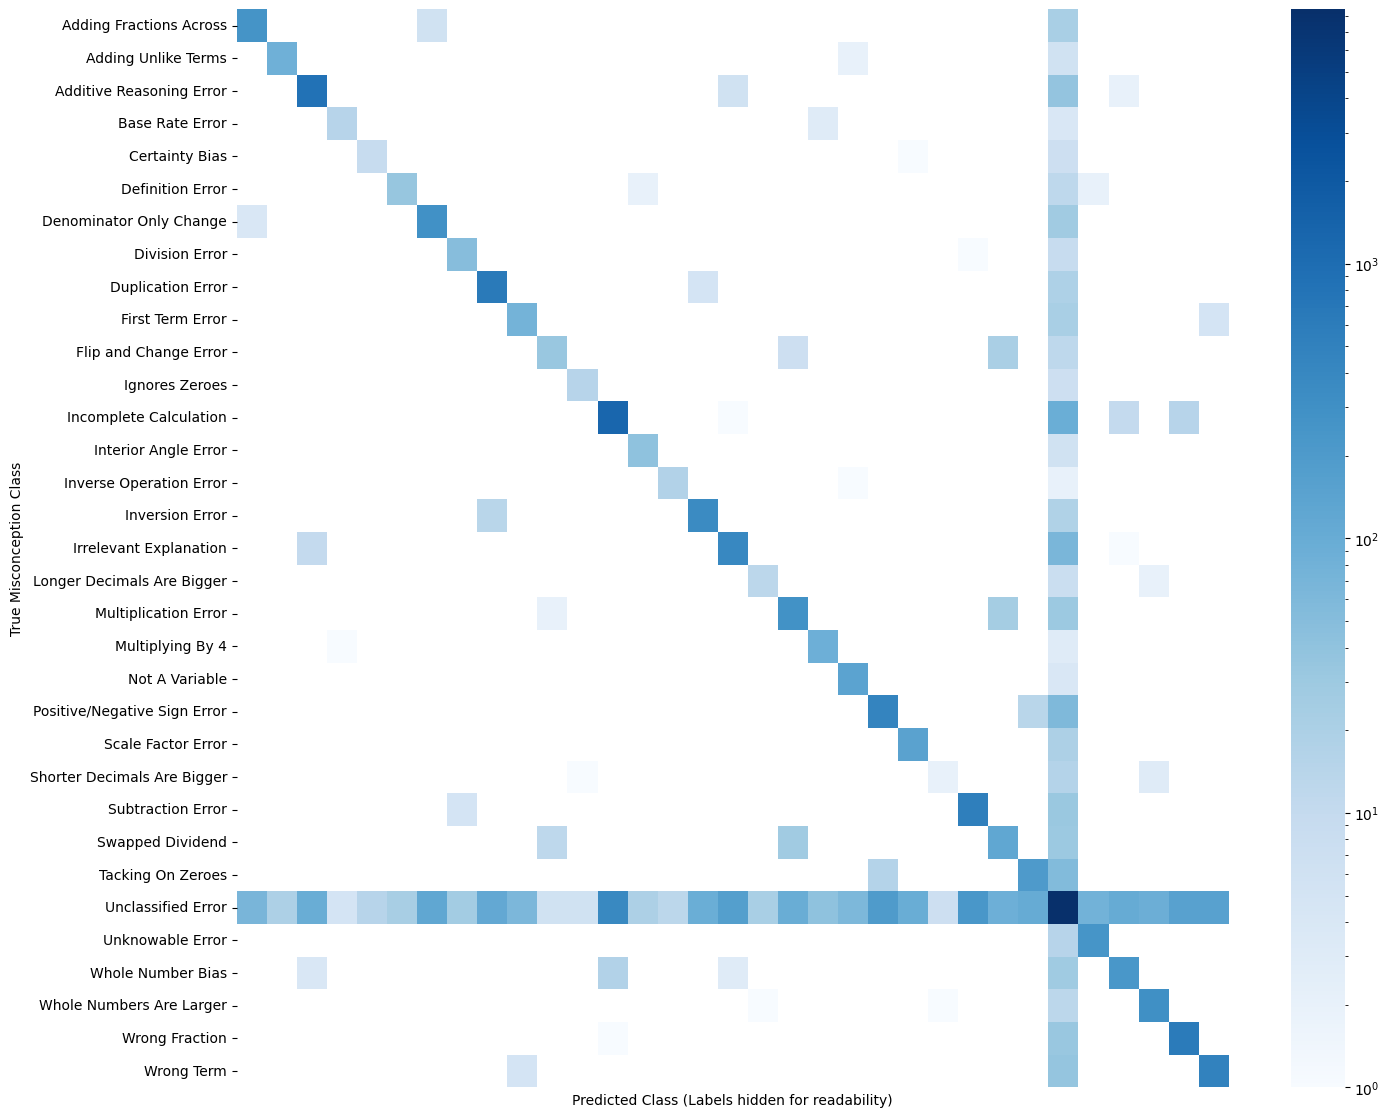

In [ ]:
unique_classes = sorted(target.unique())
cm = confusion_matrix(oof_y_true, oof_y_pred, labels=unique_classes)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, cmap='Blues', xticklabels=False, yticklabels=unique_classes,
            norm=plt.matplotlib.colors.LogNorm())
plt.ylabel('True Misconception Class')
plt.xlabel('Predicted Class (Labels hidden for readability)')
plt.show()

## 6. Testing for final metrics

In [ ]:
# Load test data
test_df = pd.read_csv("/content/val_BLvsLLM.csv")
test_df['Text_Input'] = (
    "Problem: " + test_df['QuestionText'] +
    " | Answer Chosen: " + test_df['MC_Answer'].astype(str) +
    " | Explanation: " + test_df['StudentExplanation']
)


test_features = test_df[['Text_Input']]
test_target = test_df['Misconception']


In [ ]:
# embed test data

X_test_emb = embedder.encode(test_features['Text_Input'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/34 [00:00<?, ?it/s]

In [ ]:
final_train_pool = Pool(X_base_emb, target)
final_test_pool = Pool(X_test_emb, test_target)

In [ ]:
optimal_iterations = int(np.mean(best_iters_per_fold) * 1.25)
print(f"\nOptimal Iterations for Final Model: {optimal_iterations}")

# Notice NO text_processing dictionary!
final_model_math = CatBoostClassifier(
    **{**best_emb_p, "iterations": optimal_iterations},
    loss_function="MultiClass",
    task_type="GPU",
    verbose=0
)
final_model_math.fit(final_train_pool)

test_target_pred_math = [p[0] for p in final_model_math.predict(final_test_pool)]

test_f1_mac_math = f1_score(test_target, test_target_pred_math, average='macro')
test_f1_wei_math = f1_score(test_target, test_target_pred_math, average='weighted')
test_acc_math = accuracy_score(test_target, test_target_pred_math)

print("="*40)
print("TEST 1: MATH FIX METRICS")
print(f"F1-Macro:    {test_f1_mac_math:.3f}")
print(f"F1-Weighted: {test_f1_wei_math:.3f}")
print(f"Accuracy:    {test_acc_math:.3f}")


Optimal Iterations for Final Model: 454
TEST 1: MATH FIX METRICS
F1-Macro:    0.660
F1-Weighted: 0.830
Accuracy:    0.828


In [ ]:
# Train on 100% of Base Set
final_model_plain = CatBoostClassifier(
    **best_emb_p,
    loss_function="MultiClass",
    task_type="GPU",
    verbose=0
)
final_model_plain.fit(final_train_pool)

test_target_pred_plain = [p[0] for p in final_model_plain.predict(final_test_pool)]

test_f1_mac_plain = f1_score(test_target, test_target_pred_plain, average='macro')
test_f1_wei_plain = f1_score(test_target, test_target_pred_plain, average='weighted')
test_acc_plain = accuracy_score(test_target, test_target_pred_plain)

print("="*40)
print("TEST 2: PLAIN BEST PARAMS METRICS")
print(f"F1-Macro:    {test_f1_mac_plain:.3f}")
print(f"F1-Weighted: {test_f1_wei_plain:.3f}")
print(f"Accuracy:    {test_acc_plain:.3f}")

TEST 2: PLAIN BEST PARAMS METRICS
F1-Macro:    0.675
F1-Weighted: 0.853
Accuracy:    0.852


In [ ]:
### ENSEMBLING APPROACH

print("\nEvaluating on Final 5% Test Set using 5-Fold Ensemble...")

# Get predicted probabilities from all 5 models saved during CV
ensemble_preds_proba = np.array([m.predict_proba(final_test_pool) for m in models])

# Soft Voting: Average the probabilities across the 5 models
avg_preds_proba = np.mean(ensemble_preds_proba, axis=0)

# Get the final class prediction by taking the argmax
test_target_pred_idx = np.argmax(avg_preds_proba, axis=1)
test_target_pred_ens = models[0].classes_[test_target_pred_idx]

# Calculate final metrics
test_f1_mac_ens = f1_score(test_target, test_target_pred_ens, average='macro')
test_f1_wei_ens = f1_score(test_target, test_target_pred_ens, average='weighted')
test_acc_ens = accuracy_score(test_target, test_target_pred_ens)

print("="*40)
print("TEST 3: ENSEMBLE METRICS")
print(f"F1-Macro:    {test_f1_mac_ens:.3f}")
print(f"F1-Weighted: {test_f1_wei_ens:.3f}")
print(f"Accuracy:    {test_acc_ens:.3f}")


Evaluating on Final 5% Test Set using 5-Fold Ensemble...
TEST 3: ENSEMBLE METRICS
F1-Macro:    0.670
F1-Weighted: 0.832
Accuracy:    0.831
